In [1]:
import numpy as np
from scipy.ndimage import uniform_filter

# --- 1️⃣ Original Matrix ---
A = np.array([
    [2, 4, 6, 1, 1],
    [3, 7, 6, 2, 0],
    [4, 7, 2, 5, 4],
    [3, 0, 6, 2, 1],
    [5, 7, 5, 1, 2]
], dtype=float)

Q = -0.5  # Order of contraharmonic mean
kr, kc = 3, 3  # Kernel size

# --- 2️⃣ Apply Contraharmonic Mean Filter ---
si = A.astype(np.float64)

# Numerator: mean of si^(Q+1)
num = uniform_filter(si ** (Q + 1), size=(kr, kc), mode='nearest')
# Denominator: mean of si^Q
den = uniform_filter(si ** Q, size=(kr, kc), mode='nearest')

# Avoid division by zero
sf = np.divide(num, den + 1e-8)

# --- 3️⃣ Display Results ---
print("Original Matrix:")
print(A)

print("\nAfter Contraharmonic Mean Filter (Resultant Matrix):")
print(np.round(sf, 3))


Original Matrix:
[[2. 4. 6. 1. 1.]
 [3. 7. 6. 2. 0.]
 [4. 7. 2. 5. 4.]
 [3. 0. 6. 2. 1.]
 [5. 7. 5. 1. 2.]]

After Contraharmonic Mean Filter (Resultant Matrix):
[[2.941 4.039 3.279 0.    0.   ]
 [3.644 4.108 3.7   0.    0.   ]
 [0.    0.    0.      nan   nan]
 [0.    0.    0.      nan   nan]
 [0.    0.    0.      nan   nan]]


C:\Users\anwar khan\AppData\Local\Temp\ipykernel_1884\873945510.py:22: RuntimeWarning: divide by zero encountered in power
  den = uniform_filter(si ** Q, size=(kr, kc), mode='nearest')


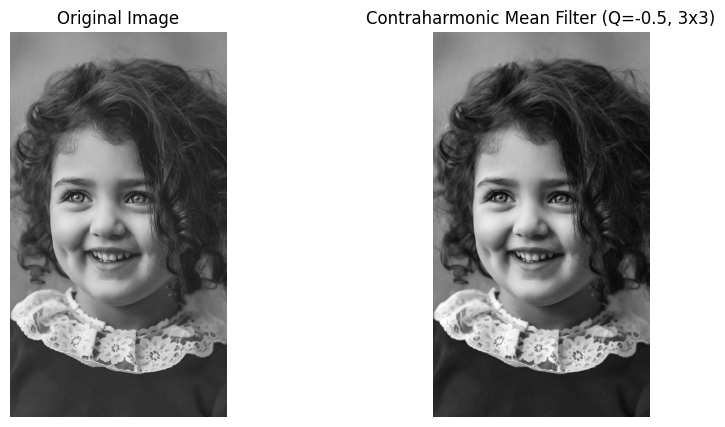

In [2]:
import cv2
import numpy as np
from scipy.ndimage import uniform_filter
import matplotlib.pyplot as plt

# --- 1️⃣ Read and prepare the image ---
img = cv2.imread('pk.jpg', cv2.IMREAD_GRAYSCALE)   # Read in grayscale
img = img.astype(np.float64) / 255.0               # Convert to [0,1] range

# --- 2️⃣ Define parameters ---
Q = -0.5   # Order of Contraharmonic Mean Filter (use +ve for pepper noise, -ve for salt noise)
k = 3      # Kernel size (3x3)

# --- 3️⃣ Apply Contraharmonic Mean Filter ---
numerator = uniform_filter(img ** (Q + 1), size=(k, k), mode='nearest')
denominator = uniform_filter(img ** Q, size=(k, k), mode='nearest')

# Avoid division by zero
filtered = np.divide(numerator, denominator + 1e-8)

# Clip values to [0,1]
filtered = np.clip(filtered, 0, 1)

# --- 4️⃣ Display results ---
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(filtered, cmap='gray')
plt.title(f'Contraharmonic Mean Filter (Q={Q}, {k}x{k})')
plt.axis('off')

plt.show()


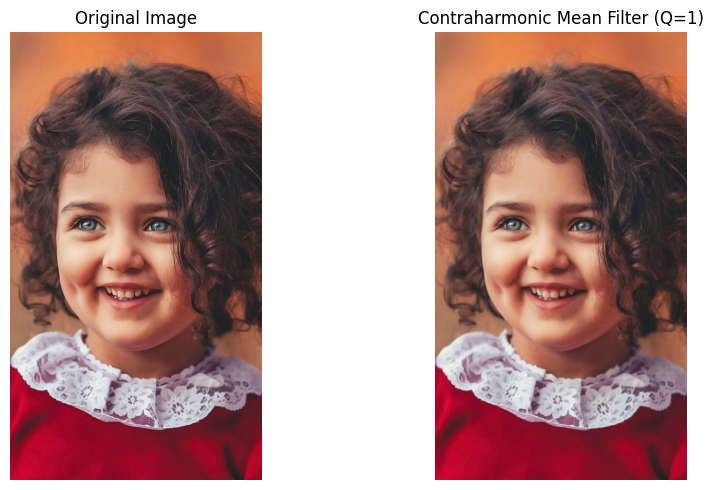

In [4]:
import cv2
import numpy as np
from scipy.ndimage import uniform_filter
import matplotlib.pyplot as plt

# --- 1️⃣ Read and prepare the image ---
I = cv2.imread('pk.jpg')                      # Load image
I = cv2.cvtColor(I, cv2.COLOR_BGR2RGB)        # Convert BGR → RGB
I = I.astype(np.float64) / 255.0              # Normalize to [0, 1]

# --- 2️⃣ Set filter parameters ---
kr, kc = 3, 3   # Kernel size
Q = 1           # Order of Contraharmonic filter (Q > 0 removes pepper noise, Q < 0 removes salt noise)

# --- 3️⃣ Apply the Contraharmonic Mean Filter (channel-wise) ---
filtered = np.zeros_like(I)
for c in range(3):  # Apply to each RGB channel
    num = uniform_filter(I[:, :, c] ** (Q + 1), size=(kr, kc), mode='nearest')
    den = uniform_filter(I[:, :, c] ** Q, size=(kr, kc), mode='nearest')
    filtered[:, :, c] = num / (den + 1e-8)

# --- 4️⃣ Display Results ---
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(I)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(np.clip(filtered, 0, 1))
plt.title(f'Contraharmonic Mean Filter (Q={Q})')
plt.axis('off')

plt.tight_layout()
plt.show()
